# Segmentación por umbralización

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.util import random_noise

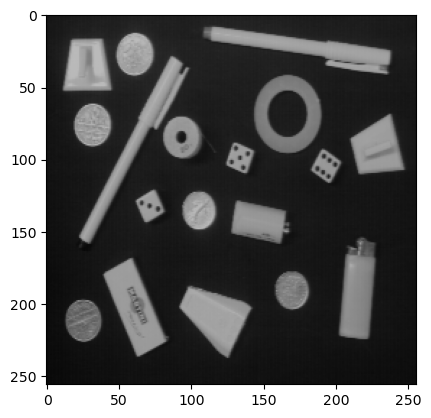

In [2]:
objectsImg = cv2.imread("images/OBJECTS.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(objectsImg, cmap="gray", vmin=0, vmax=255)

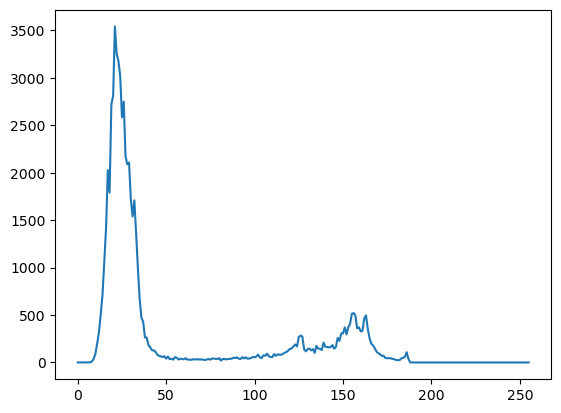

In [3]:
hist = cv2.calcHist([objectsImg], [0], None, [256], [0, 256])
plt.plot(hist)

Algoritmo de Umbralización

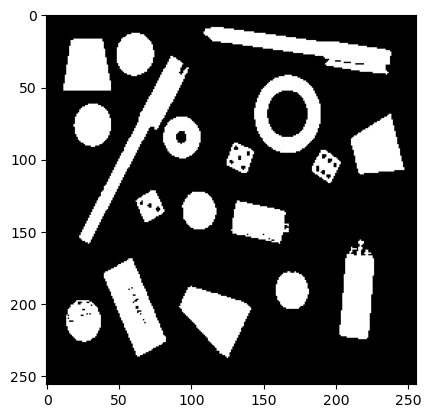

In [4]:
thres_value, thres_image = cv2.threshold(objectsImg, 90, 255, cv2.THRESH_BINARY)
plt.imshow(thres_image, cmap='gray', vmin=0, vmax=255)

Algoritmo Otsu

In [5]:
thres_value_ot, thres_image_ot = cv2.threshold(objectsImg, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
thres_value_ot

84.0

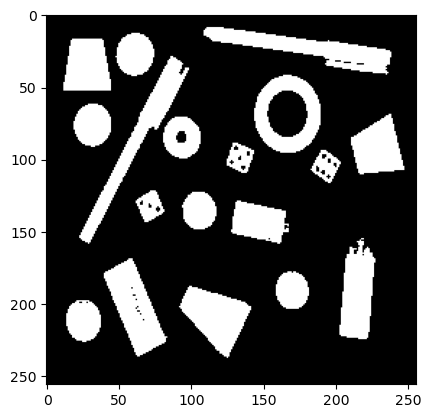

In [6]:
plt.imshow(thres_image_ot, cmap='gray', vmin=0, vmax=255)

Ruido Gausiano

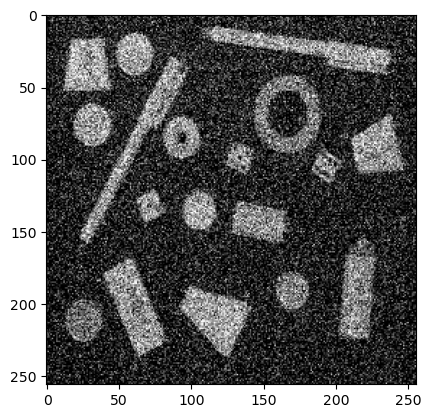

In [7]:
float_image = random_noise(objectsImg, mode='gaussian', mean=0,  var=0.05)
noised_image = (float_image * 255).astype(np.uint8)
plt.imshow(noised_image, cmap="gray", vmin=0, vmax=255)

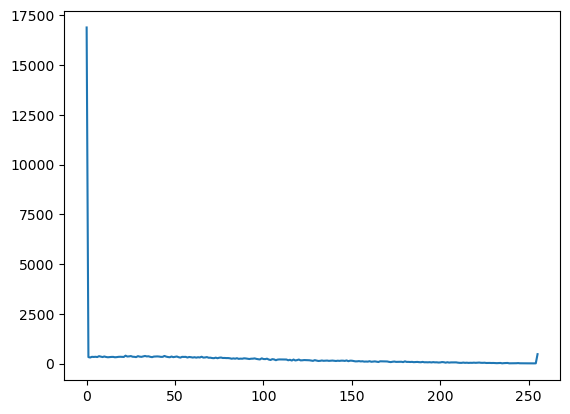

In [8]:
hist = cv2.calcHist([noised_image], [0], None, [256], [0, 256])
plt.plot(hist)

Lo que vemos que sucede es que ahora nuestra imagen tiene ruido, es decir parece que se hubiese granulado disminuyendo la calidad de los objetos que podíamos observar. Esto se debe a que el ruido Gaussiano lo que hace es asignar a cada píxel un valor aleatorio que sigue una distribución Gaussiana de media 0 y con varianza de 0.05, es decir suma o resta valores a cada píxel generando este efecto granulado.

*Umbralizaciones nuevamente*

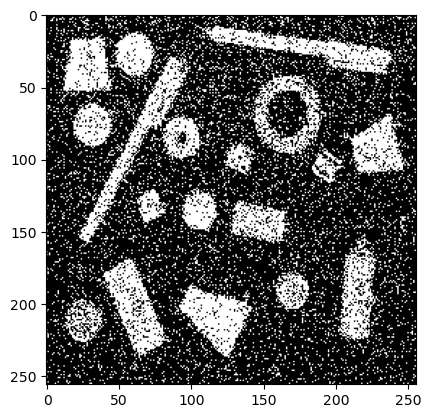

In [9]:
thres_value, thres_image = cv2.threshold(noised_image, 90, 255, cv2.THRESH_BINARY)
plt.imshow(thres_image, cmap='gray', vmin=0, vmax=255)

In [10]:
thres_value_ot, thres_image_ot = cv2.threshold(noised_image, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
thres_value_ot

84.0

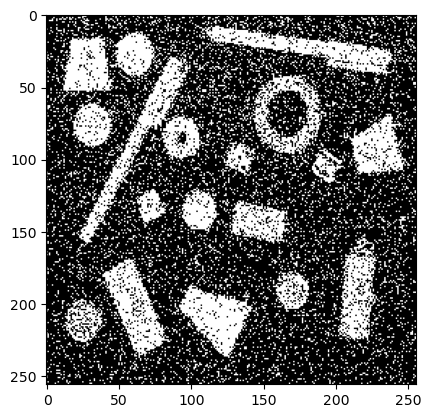

In [11]:
plt.imshow(thres_image_ot, cmap='gray', vmin=0, vmax=255)

Lo que podemos ver ahora es que el resultado de la umbralización fue fuertemente afectado por el ruido gaussiano introducido y vemos puntos negros en las zonas blancas y puntos blancos en zonas negras. Esto se debe a que el ruido hace que se sumen o resten valores aleatorios, haciendo que un valor que antes era claramente negro ahora sea considerado blanco por el ruido introducido.

*Imagen text*

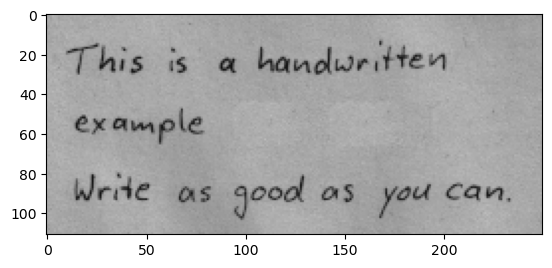

In [12]:
textImg = cv2.imread("images/TEXT.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(textImg, cmap='gray', vmin=0, vmax=255)

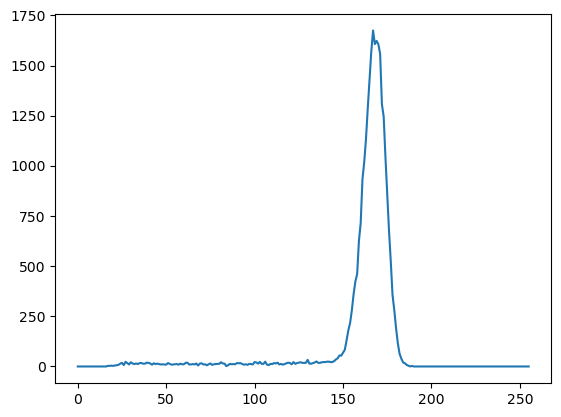

In [13]:
hist = cv2.calcHist([textImg], [0], None, [256], [0, 256])
plt.plot(hist)

Sombra circular

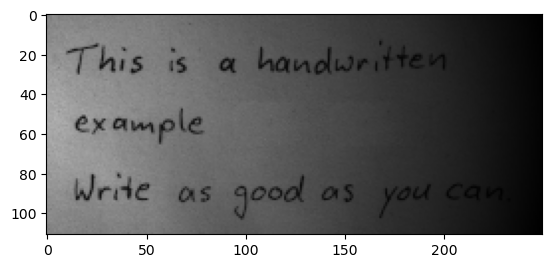

In [23]:
rows, cols = textImg.shape
x, y = np.meshgrid(np.arange(cols), np.arange(rows))
#Cálculo del centro
cx, cy = 0, rows//2
#Cálculo del radio y distancia posible
distance = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)
max_dist = np.sqrt((rows//2)**2 + cols**2)

#Aplicación del gradiente
spot_shading = 1 - (distance / max_dist)  
spot_image = textImg * spot_shading

spot_image = spot_image.astype(np.uint8)

plt.imshow(spot_image, cmap='gray', vmin=0, vmax=255)

Sombra sinusoidal

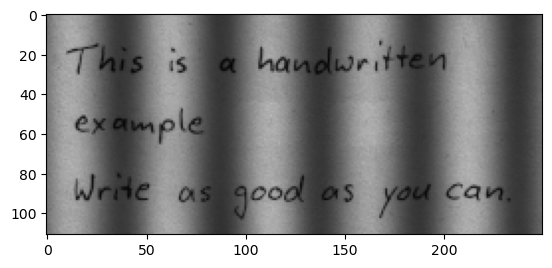

In [37]:
# Cantidad de perturbaciones
frequency = 50 
#Intensidad de los picos
amplitude = 0.5  

#Cálculo y aplicación del efecto
sinusoidal_shading = (1 + amplitude * np.sin(2 * np.pi * x / frequency)) / 1.5
sinusoidal_image = textImg * sinusoidal_shading

sinusoidal_image = sinusoidal_image.astype(np.uint8)
plt.imshow(sinusoidal_image, cmap='gray', vmin=0, vmax=255)

Umbralización Otsu

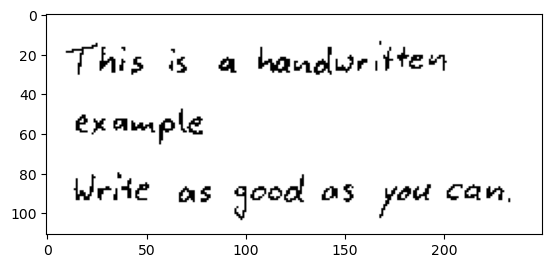

In [38]:
thres_value_ot, thres_image_ot = cv2.threshold(textImg, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
plt.imshow(thres_image_ot, cmap='gray', vmin=0, vmax=255)

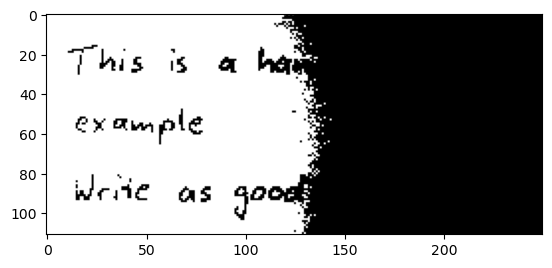

In [40]:
thres_value_ot1, thres_image_ot1 = cv2.threshold(spot_image, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
plt.imshow(thres_image_ot1, cmap='gray', vmin=0, vmax=255)

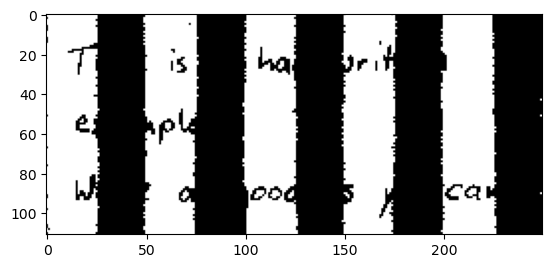

In [42]:
thres_value_ot2, thres_image_ot2 = cv2.threshold(sinusoidal_image, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
plt.imshow(thres_image_ot2, cmap='gray', vmin=0, vmax=255)

Lo que vemos en nuestras imágenes es que ahora la umbralización está presentando fallos, esto se debe a que al introducir la sombra lo que ocurre es que el fondo de la imágen deja de ser homogéneo, es decir ahora el fondo blanco tiene varios tonos, debido a esto nuestra imágen ya no se compone de dos tonos claros sino que hay una diversidad de grises introducidos por las sobras. Esto hace que OTSU se confunda y no pueda determinar con claridad donde está la separación entre el texto y el fondo. De esta forma nuestro algoritmo hace que tonos de blanco que antes eran más claros y segmentados tomen por ejemplo valores oscuros debido a la sombra y que el algoritmo piense que son texto y los pinte de negro como ocurre con los ejemplos anteriores.

*Umbralización Local*

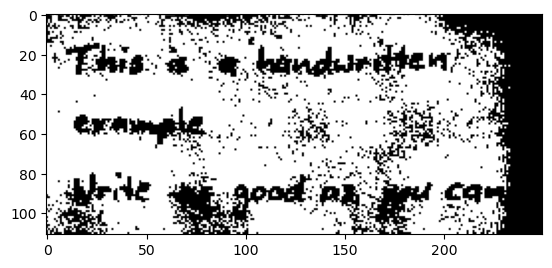

In [54]:
from skimage.filters import threshold_local

ti = threshold_local(spot_image, block_size=51, method='mean')
binary_image = spot_image > ti
thresholded_image = (binary_image*255).astype('uint8')

plt.imshow(thresholded_image, cmap='gray', vmin=0, vmax=255)


Si usamos offset (un márgen de seguridad), logramos eliminar un poco el ruido y la imágen se vé aún mejor.

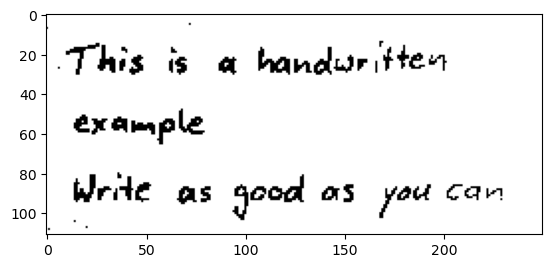

In [55]:
ti = threshold_local(spot_image, block_size=51, method='mean', offset=10)
binary_image = spot_image > ti
thresholded_image = (binary_image*255).astype('uint8')

plt.imshow(thresholded_image, cmap='gray', vmin=0, vmax=255)


El resultado cambia considerablemente en comparación con Otsu, esto implica que al hacer una umbralización local, es decir calculando un umbral por vecindario logramos que la sombra o ruido no afecte considerablemnente el resultado de nuestra umbralización. Como se mencionó anteriormente para reducir el ruido se puede usar un offset de seguridad que garantiza que un pixel se marque como oscuro o claro teniendo un margen para que por casualidad el promedio quede en el lado incorrecto del umbral.